EXERCISE 2: RK2 (EULER'S HALFSTEP METHOD)
ODE: dy/dx = -y - 3x, y(0) = 1
Exact solution at x = 2.0: y(2) = -3.2706705665

TABLE 1: RK2 RESULTS
k   numSteps   h            Y[-1,0]            E[k]               E[k]/E[k+1]    
--------------------------------------------------------------------------------
0   10         0.2000       -3.2748960627      4.2254961987e-03   ---            
1   20         0.1000       -3.2716449150      9.7434853094e-04   4.3367         
2   40         0.0500       -3.2709048541      2.3428761102e-04   4.1588         
3   80         0.0250       -3.2707280302      5.7463677842e-05   4.0771         
4   160        0.0125       -3.2706847971      1.4230623550e-05   4.0380         
5   320        0.0063       -3.2706741074      3.5409412260e-06   4.0189         
--------------------------------------------------------------------------------

QUESTION 4: ESTIMATE ORDER OF ACCURACY

Error ratios (E[k]/E[k+1]):
  E[0]/E[1] = 4.3367
  E[1]/E[2] = 4.1588
  E[2]/E[3

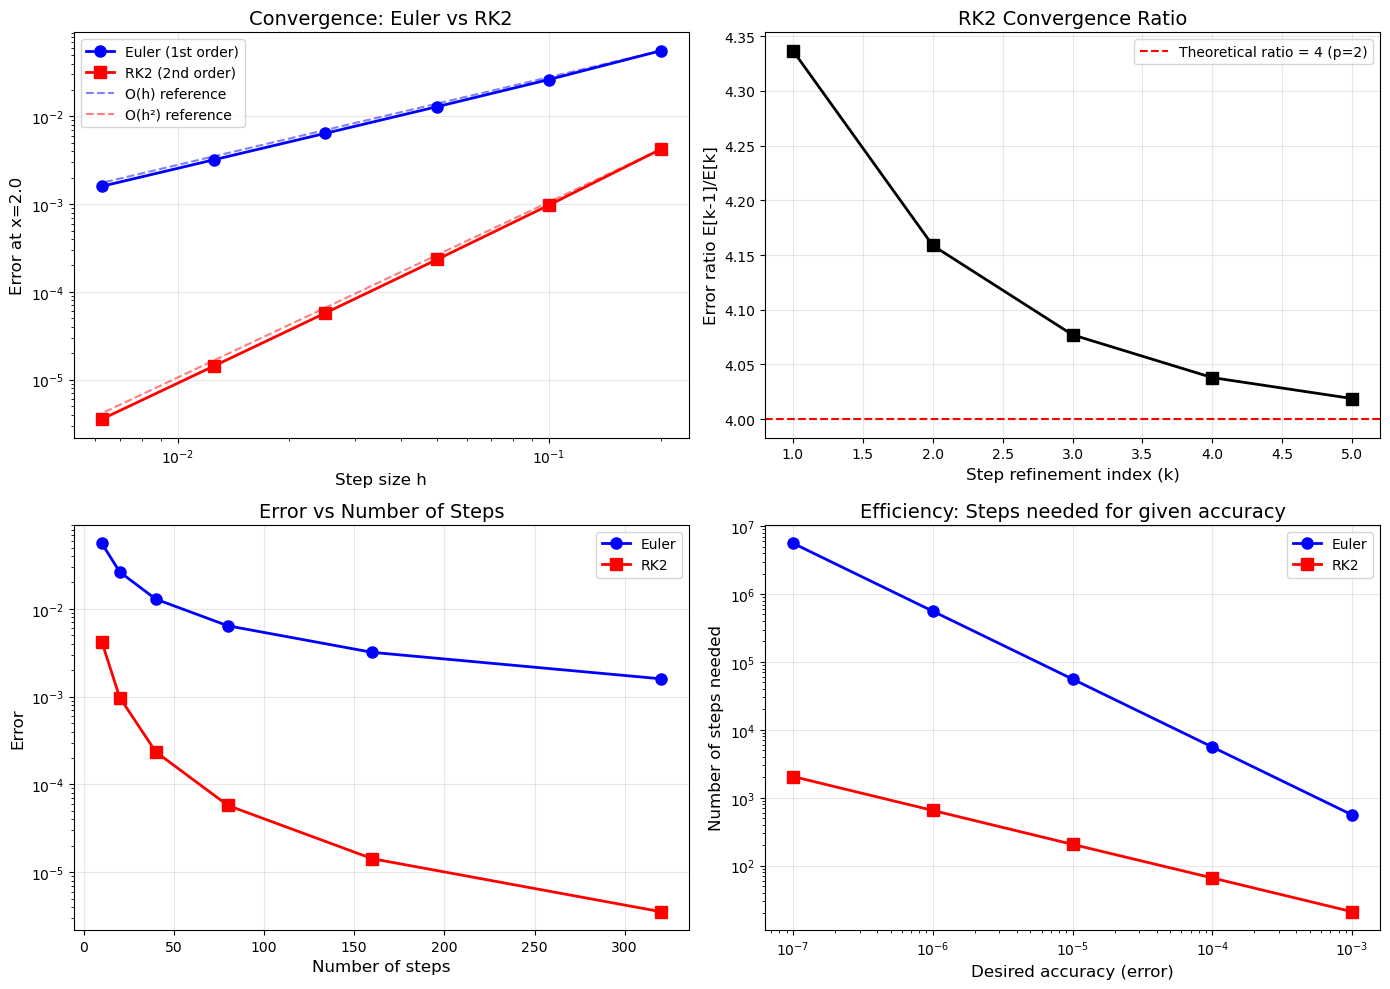


✓ Plot saved as 'exercise2_plots.png'

Exercise 2 completed successfully!


In [1]:
"""
exercise2.py - Exercise 2: RK2 (Euler's Halfstep Method)
ODE: dy/dx = -y - 3x, y(0) = 1, from x=0 to x=2
"""

import numpy as np
import matplotlib.pyplot as plt

# ============================================
# 1. RK2 FUNCTION (Euler's Halfstep Method)
# ============================================
def rk2(f_ode, xRange, yInitial, numSteps):
    """
    x, y = rk2(f_ode, xRange, yInitial, numSteps)
    
    Use Euler's halfstep method (RK2) on one or more ODEs dy/dx = f_ode(x,y).
    """
    x = np.zeros(numSteps + 1)
    y = np.zeros((numSteps + 1, np.size(yInitial)))
    dx = (xRange[1] - xRange[0]) / numSteps
    
    for k in range(0, numSteps + 1):
        if k == 0:
            x[0] = xRange[0]
            y[0, :] = yInitial
        else:
            xa = x[k-1] + dx/2
            ya = y[k-1, :] + (dx/2) * f_ode(x[k-1], y[k-1, :])
            x[k] = x[k-1] + dx
            y[k, :] = y[k-1, :] + dx * f_ode(xa, ya)
    
    if y.shape[1] == 1:
        y = y.flatten()
    return x, y


# ============================================
# 2. FORWARD EULER FUNCTION (for comparison)
# ============================================
def forward_euler(f_ode, xRange, yInitial, numSteps):
    x = np.zeros(numSteps + 1)
    y = np.zeros((numSteps + 1, np.size(yInitial)))
    dx = (xRange[1] - xRange[0]) / numSteps
    
    for k in range(0, numSteps + 1):
        if k == 0:
            x[0] = xRange[0]
            y[0, :] = yInitial
        else:
            x[k] = x[k - 1] + dx
            y[k, :] = y[k - 1, :] + dx * f_ode(x[k - 1], y[k - 1, :])
    
    if y.shape[1] == 1:
        y = y.flatten()
    return x, y


# ============================================
# 3. ODE AND EXACT SOLUTION
# ============================================
def expm_ode(x, y):
    """dy/dx = -y - 3x"""
    return -y - 3.0 * x

def exact_solution(x):
    """y(x) = -2e^(-x) - 3x + 3"""
    return -2.0 * np.exp(-x) - 3.0 * x + 3.0


# ============================================
# 4. MAIN FUNCTION
# ============================================
def main():
    # Problem setup
    xRange = np.array([0.0, 2.0])
    yInit = 1.0
    
    # Step sizes (k = 0 to 5)
    numSteps_list = [10, 20, 40, 80, 160, 320]
    h_list = [0.2, 0.1, 0.05, 0.025, 0.0125, 0.00625]
    
    # Euler errors from Exercise 1
    euler_errors = [5.5922e-02, 2.6283e-02, 1.2900e-02, 6.4079e-03, 3.1953e-03, 1.5963e-03]
    
    exact_at_2 = exact_solution(2.0)
    
    print("="*80)
    print("EXERCISE 2: RK2 (EULER'S HALFSTEP METHOD)")
    print("ODE: dy/dx = -y - 3x, y(0) = 1")
    print(f"Exact solution at x = 2.0: y(2) = {exact_at_2:.10f}")
    print("="*80)
    
    # ============================================
    # PART 1: Solve with RK2 and create table
    # ============================================
    print("\n" + "="*80)
    print("TABLE 1: RK2 RESULTS")
    print("="*80)
    print(f"{'k':<3} {'numSteps':<10} {'h':<12} {'Y[-1,0]':<18} {'E[k]':<18} {'E[k]/E[k+1]':<15}")
    print("-"*80)
    
    results = []
    errors = []
    
    for k, numSteps in enumerate(numSteps_list):
        h = h_list[k]
        x, y = rk2(expm_ode, xRange, yInit, numSteps)
        
        # Get final y value (at x=2.0)
        if y.ndim == 1:
            y_final = y[-1]
        else:
            y_final = y[-1, 0]
        
        # Calculate error
        error = abs(y_final - exact_at_2)
        errors.append(error)
        
        results.append({
            'k': k,
            'numSteps': numSteps,
            'h': h,
            'y_final': y_final,
            'error': error
        })
        
        # Calculate ratio
        if k == 0:
            ratio_str = "---"
        else:
            ratio = errors[k-1] / errors[k]
            ratio_str = f"{ratio:.4f}"
        
        print(f"{k:<3} {numSteps:<10} {h:<12.4f} {y_final:<18.10f} {error:<18.10e} {ratio_str:<15}")
    
    print("-"*80)
    
    # ============================================
    # PART 2: Estimate order of accuracy (Question 4)
    # ============================================
    print("\n" + "="*80)
    print("QUESTION 4: ESTIMATE ORDER OF ACCURACY")
    print("="*80)
    
    ratios = [errors[i-1]/errors[i] for i in range(1, len(errors))]
    avg_ratio = np.mean(ratios)
    
    print(f"\nError ratios (E[k]/E[k+1]):")
    for i, r in enumerate(ratios, 1):
        print(f"  E[{i-1}]/E[{i}] = {r:.4f}")
    
    print(f"\nAverage ratio: {avg_ratio:.4f}")
    print(f"Theoretical ratio for 2nd order method (p=2): 4.00")
    
    # Estimate p: ratio = 2^p
    p_estimated = np.log2(avg_ratio)
    print(f"\nEstimated order p = log2({avg_ratio:.4f}) = {p_estimated:.4f}")
    print(f"\n✓ Conclusion: RK2 is {round(p_estimated)}nd order accurate (p = {round(p_estimated)})")
    
    # ============================================
    # PART 3: Compare Euler vs RK2
    # ============================================
    print("\n" + "="*80)
    print("TABLE 2: COMPARISON - EULER vs RK2")
    print("="*80)
    print(f"{'k':<3} {'numSteps':<10} {'Step size h':<12} {'Euler Error':<18} {'RK2 Error':<18}")
    print("-"*80)
    
    for i in range(len(numSteps_list)):
        print(f"{i:<3} {numSteps_list[i]:<10} {h_list[i]:<12.4f} {euler_errors[i]:<18.10e} {errors[i]:<18.10e}")
    
    print("-"*80)
    
    # ============================================
    # Question: Steps for Euler to match RK2 at numSteps=10
    # ============================================
    print("\n" + "="*80)
    print("QUESTION: How many steps does Euler need to match RK2 at numSteps=10?")
    print("="*80)
    
    rk2_error_at_10 = errors[0]
    print(f"\nRK2 error with numSteps=10: {rk2_error_at_10:.10e}")
    
    for i, euler_err in enumerate(euler_errors):
        if euler_err <= rk2_error_at_10:
            print(f"Euler achieves similar accuracy at numSteps = {numSteps_list[i]}")
            print(f"Euler error: {euler_err:.10e}")
            break
    
    # ============================================
    # Question: Steps for Euler to match RK2 at numSteps=320
    # ============================================
    print("\n" + "="*80)
    print("QUESTION: How many steps does Euler need to match RK2 at numSteps=320?")
    print("="*80)
    
    rk2_error_at_320 = errors[-1]
    print(f"\nRK2 error with numSteps=320: {rk2_error_at_320:.10e}")
    
    # Error scaling: Euler error ∝ 1/N, RK2 error ∝ 1/N²
    # C_Euler = error * N,  C_RK2 = error * N²
    
    C_Euler = euler_errors[-1] * numSteps_list[-1]
    C_RK2 = rk2_error_at_320 * (numSteps_list[-1]**2)
    
    required_steps = int(np.ceil(C_Euler / rk2_error_at_320))
    
    print(f"\nError scaling analysis:")
    print(f"  Euler: error × N = {C_Euler:.4e} (constant)")
    print(f"  RK2:   error × N² = {C_RK2:.4e} (constant)")
    print(f"\n  Required Euler steps = C_Euler / RK2_error = {required_steps}")
    print(f"  Ratio: Euler needs {required_steps/320:.1f}× more steps than RK2!")
    
    print(f"\nExplanation:")
    print(f"  Euler is 1st order (error ∝ h ∝ 1/N)")
    print(f"  RK2 is 2nd order (error ∝ h² ∝ 1/N²)")
    print(f"  To achieve the same error, Euler needs N_Euler ≈ N_RK2² × (C_Euler/C_RK2)")
    print(f"  N_Euler ≈ {required_steps} steps while RK2 only needs 320 steps")
    
    # ============================================
    # Verification
    # ============================================
    print("\n" + "="*80)
    print("VERIFICATION: Euler with estimated steps")
    print("="*80)
    
    test_steps = [320, 640, 1280, 2560, 5120, required_steps, required_steps*2]
    
    print(f"\n{'numSteps':<12} {'Euler Error':<20} {'Better than RK2(320)?':<25}")
    print("-"*60)
    
    for steps in test_steps:
        x_e, y_e = forward_euler(expm_ode, xRange, yInit, steps)
        y_final = y_e[-1] if y_e.ndim == 1 else y_e[-1, 0]
        error = abs(y_final - exact_at_2)
        is_better = error < rk2_error_at_320
        print(f"{steps:<12} {error:<20.10e} {str(is_better):<25}")
    
    # ============================================
    # PLOTTING
    # ============================================
    plot_results(results, euler_errors, h_list, numSteps_list)
    
    print("\n" + "="*80)
    print("Exercise 2 completed successfully!")
    print("="*80)


def plot_results(rk2_results, euler_errors, h_list, numSteps_list):
    """Generate comparison plots"""
    
    rk2_errors = [r['error'] for r in rk2_results]
    h_vals = h_list
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Plot 1: Error vs step size (log-log)
    ax1 = axes[0, 0]
    ax1.loglog(h_vals, euler_errors, 'bo-', linewidth=2, markersize=8, label='Euler (1st order)')
    ax1.loglog(h_vals, rk2_errors, 'rs-', linewidth=2, markersize=8, label='RK2 (2nd order)')
    
    # Reference lines
    ref_1st = euler_errors[0] * (np.array(h_vals) / h_vals[0])
    ref_2nd = rk2_errors[0] * ((np.array(h_vals) / h_vals[0])**2)
    ax1.loglog(h_vals, ref_1st, 'b--', alpha=0.5, label='O(h) reference')
    ax1.loglog(h_vals, ref_2nd, 'r--', alpha=0.5, label='O(h²) reference')
    
    ax1.set_xlabel('Step size h', fontsize=12)
    ax1.set_ylabel('Error at x=2.0', fontsize=12)
    ax1.set_title('Convergence: Euler vs RK2', fontsize=14)
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    
    # Plot 2: RK2 error ratios (should approach 4)
    ax2 = axes[0, 1]
    rk2_ratios = [rk2_results[i-1]['error'] / rk2_results[i]['error'] for i in range(1, len(rk2_results))]
    ax2.plot(range(1, len(rk2_ratios)+1), rk2_ratios, 'ks-', linewidth=2, markersize=8)
    ax2.axhline(y=4.0, color='r', linestyle='--', label='Theoretical ratio = 4 (p=2)')
    ax2.set_xlabel('Step refinement index (k)', fontsize=12)
    ax2.set_ylabel('Error ratio E[k-1]/E[k]', fontsize=12)
    ax2.set_title('RK2 Convergence Ratio', fontsize=14)
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    
    # Plot 3: Error vs numSteps
    ax3 = axes[1, 0]
    ax3.semilogy(numSteps_list, euler_errors, 'bo-', label='Euler', linewidth=2, markersize=8)
    ax3.semilogy(numSteps_list, rk2_errors, 'rs-', label='RK2', linewidth=2, markersize=8)
    ax3.set_xlabel('Number of steps', fontsize=12)
    ax3.set_ylabel('Error', fontsize=12)
    ax3.set_title('Error vs Number of Steps', fontsize=14)
    ax3.grid(True, alpha=0.3)
    ax3.legend()
    
    # Plot 4: Efficiency comparison
    ax4 = axes[1, 1]
    
    # Estimate steps needed for different accuracies
    accuracy_targets = [1e-3, 1e-4, 1e-5, 1e-6, 1e-7]
    
    euler_steps_needed = []
    rk2_steps_needed = []
    
    for target in accuracy_targets:
        # Euler: error ∝ 1/N
        euler_N = int(np.ceil(euler_errors[0] * numSteps_list[0] / target))
        euler_steps_needed.append(euler_N)
        
        # RK2: error ∝ 1/N²
        rk2_N = int(np.ceil(np.sqrt(rk2_errors[0] * (numSteps_list[0]**2) / target)))
        rk2_steps_needed.append(rk2_N)
    
    ax4.loglog(accuracy_targets, euler_steps_needed, 'bo-', label='Euler', linewidth=2, markersize=8)
    ax4.loglog(accuracy_targets, rk2_steps_needed, 'rs-', label='RK2', linewidth=2, markersize=8)
    ax4.set_xlabel('Desired accuracy (error)', fontsize=12)
    ax4.set_ylabel('Number of steps needed', fontsize=12)
    ax4.set_title('Efficiency: Steps needed for given accuracy', fontsize=14)
    ax4.grid(True, alpha=0.3)
    ax4.legend()
    
    plt.tight_layout()
    plt.savefig('exercise2_plots.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("\n✓ Plot saved as 'exercise2_plots.png'")


# ============================================
# RUN THE CODE
# ============================================
if __name__ == "__main__":
    main()